## Perceptron with offset
In the previous notebook, the decision boundary was through the origin point (0,0). IN this notebook we extend the example to show how the Perceptron can be modified to help find a decsion boundary that doesn't run through the origin.

In [1]:
import numpy as np
import numpy.random
import matplotlib.pyplot as plt
%matplotlib inline

## A more complex example

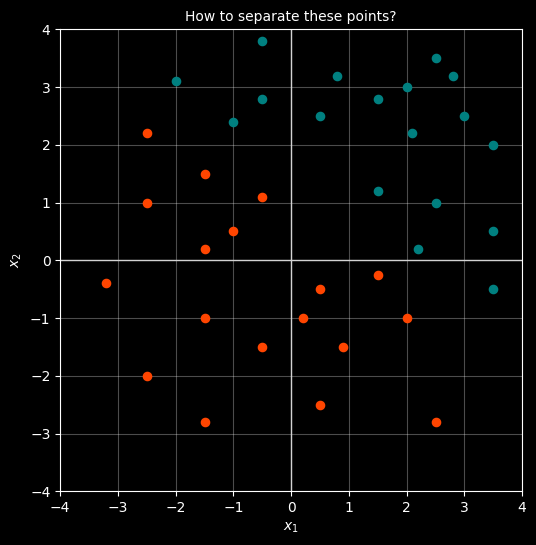

In [3]:
# More points: teal above/right of boundary, red below/left
blue_pts = np.array([
    [ 2.0,  3.0],
    [ 3.0,  2.5],
    [ 2.5,  3.5],
    [ 3.5,  2.0],
    [ 1.5,  2.8],
    [ 2.8,  3.2],
    [-2, 3.1],
    [-1, 2.4],
    [-0.5, 3.8],
    [2.5, 1.0],
    [3.5, 0.5],
    [0.5, 2.5],
    [1.5, 1.2],
    [2.1, 2.2],
    [3.5, -0.5],
    [0.8, 3.2],
    [-0.5, 2.8],
    [2.2, 0.2]
])

red_pts = np.array([
    [-0.5, 1.1],
    [-1.0,  0.5],
    [-2.5,  1.0],
    [ 0.5, -0.5],
    [-1.5,  0.2],
    [ 0.2, -1.0],
    [-1.5, 1.5],
    [-2.5, 2.2],
    [-1.5, -1],
    [-0.5, -1.5],
    [2,-1],
    [1.5, -.25],
    [0.9, -1.5],
    [-2.5, -2],
    [-3.2, -0.4],
    [-1.5, -2.8],
    [2.5, -2.8],
    [0.5, -2.5]
])


with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # plot points
    ax.scatter(blue_pts[:,0], blue_pts[:,1], s=35, color="teal", zorder=3)
    ax.scatter(red_pts[:,0],  red_pts[:,1],  s=35, color="orangered", zorder=3)
    
    
    # axes + grid
    ax.axhline(0, color="lightgray", linewidth=1)
    ax.axvline(0, color="lightgray", linewidth=1)

    
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_title(r"How to separate these points?", fontsize="10")
    
    plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate(W, x):
    """
    Calculate the dot product of W and x (including bias term).
    Return 1 if the result is >= 0, else -1.
    """
    dot_prod = np.dot(W, x)
    return 1 if dot_prod >= 0 else -1

def update(W, x, y_label, learning_rate=0.1):
    """
    Update W by adding the misclassified vector (including bias) scaled by its label.
    Returns the updated W.
    """
    W = W + learning_rate * y_label * x
    return W

In [12]:
def print_status(epoch, W, predictions):
    """Print the classification results for a given epoch."""
    print(f"\n{'='*70}")
    print(f"EPOCH {epoch + 1}")
    print(f"{'='*70}")
    print(f"Weight vector: W = {np.round(W[:2], 3)}, Bias: {round(W[2], 3)}")
    print(f"Total misclassifications: {sum(p != yi for p, yi in zip(predictions, y))}\n")

    print(f"{'Idx':<5} {'Point':<22} {'Actual':<10} {'Predicted':<10} {'Dot Prod':<12} {'Status':<10}")
    print("-" * 70)
    for idx, (xi, yi, pred) in enumerate(zip(X, y, predictions)):
        actual_label = "blue" if yi   == 1 else "red"
        pred_label   = "blue" if pred == 1 else "red"
        dot_prod     = np.dot(W, xi)
        status       = "✓ CORRECT" if pred == yi else "✗ WRONG"
        print(f"{idx:<5} {str(xi[:2]):<22} {actual_label:<10} {pred_label:<10} {dot_prod:<12.3f} {status:<10}")

    if all(p == yi for p, yi in zip(predictions, y)):
        print("\n✓ NO MISCLASSIFICATIONS - CONVERGED!")


def plot_decision_boundary(W, epoch):
    """Plot the data points, decision boundary and weight vector for a given W."""
    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=(5, 5))

        # Plot points (using original 2D coordinates, not augmented)
        ax.scatter(blue_pts[:, 0], blue_pts[:, 1], s=25, color="lightblue", zorder=3)
        ax.scatter(red_pts[:, 0],  red_pts[:, 1],  s=25, color="orangered", zorder=3)

        # Decision boundary: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b) / w2
        x_range = np.linspace(-5, 5, 100)
        if abs(W[1]) > 0.01:
            x2_boundary = -(W[0] * x_range + W[2]) / W[1]
            ax.plot(x_range, x2_boundary, color="yellow", linewidth=2)
        else:
            ax.axvline(-W[2] / W[0], color="yellow", linewidth=2)

        # Weight vector (2D component only)
        ax.arrow(0, 0, W[0], W[1],
                 length_includes_head=True,
                 head_width=0.15, head_length=0.2,
                 linewidth=2, color="fuchsia")

        # Axes and grid
        ax.axhline(0, color="grey", linewidth=1)
        ax.axvline(0, color="grey", linewidth=1)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(-5, 5)
        ax.set_ylim(-5, 5)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel(r"$x_1$", fontsize=9)
        ax.set_ylabel(r"$x_2$", fontsize=9)
        ax.set_title(f"Epoch {epoch + 1}: W = {np.round(W[:2], 2)}, b = {round(W[2], 2)}", fontsize=10)

        plt.tight_layout()
        plt.show()

ValueError: shapes (3,) and (4,) not aligned: 3 (dim 0) != 4 (dim 0)